# Clasificación de variedades de fríjol seco con un MLP en PyTorch

**Momento Evaluativo I — Introducción al Aprendizaje Profundo**

Este cuaderno implementa un problema de clasificación multiclase con el Dry Bean Dataset de UCI. El análisis y las conclusiones se basan exclusivamente en la ejecución real.

## Problema, objetivos y conceptos

Se busca predecir la variedad de un fríjol seco a partir de 16 características numéricas. Una muestra es una fila, las características son sus variables predictoras y la etiqueta es `Class`. Como existen siete variedades, es una clasificación multiclase.

El modelo será un perceptrón multicapa (MLP): una red de capas densas que aprende transformaciones no lineales mediante pesos, sesgos y activaciones ReLU. La salida tendrá siete logits y `CrossEntropyLoss` recibirá índices enteros; por eso no se agrega `Softmax`.

## 1. Rutas, librerías, reproducibilidad y dispositivo

Esta celda localiza `E_1` de forma robusta y crea únicamente las carpetas de salida faltantes. También importa el código reutilizable y reporta si se usará GPU o CPU.

In [1]:
from pathlib import Path
import sys

candidatas = [Path.cwd(), *Path.cwd().parents]
E1_DIR = next((p for p in candidatas if p.name == 'E_1'), None)
if E1_DIR is None:
    E1_DIR = next((p / 'E_1' for p in candidatas if (p / 'E_1').is_dir()), None)
if E1_DIR is None:
    raise FileNotFoundError('No se encontró la carpeta E_1')
DATA_PATH = E1_DIR / 'data' / 'raw' / 'Dry_Bean_Dataset.xlsx'
OUTPUTS_DIR = E1_DIR / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figuras'
METRICS_DIR = OUTPUTS_DIR / 'metricas'
MODELS_DIR = OUTPUTS_DIR / 'modelos'
for folder in (FIGURES_DIR, METRICS_DIR, MODELS_DIR):
    folder.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(E1_DIR / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from entrenar_mlp import ejecutar_experimento
from visualizar_resultados import generar_graficas

print('E_1:', E1_DIR)
print('Dataset:', DATA_PATH)
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

E_1: C:\ITM\AprendizajeProfundo\Deep_learning_training\E_1
Dataset: C:\ITM\AprendizajeProfundo\Deep_learning_training\E_1\data\raw\Dry_Bean_Dataset.xlsx
PyTorch: 2.14.0+cu130
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4070 Ti


## 2. Dataset y carga

El dataset oficial debe existir en la ruta indicada. Si falta, se ejecuta el descargador oficial de UCI. Luego se mostrarán dimensiones, primeras filas, tipos, estadísticas, faltantes, duplicados y distribución de clases.

In [2]:
if not DATA_PATH.exists():
    from descargar_dataset import descargar_dataset
    descargar_dataset(DATA_PATH)
print('Dataset encontrado:', DATA_PATH.exists())
df_preview = pd.read_excel(DATA_PATH)
print('Dimensiones:', df_preview.shape)
display(df_preview.head())
display(df_preview.dtypes.to_frame('tipo'))
display(df_preview.describe().T)
print('Faltantes totales:', int(df_preview.isna().sum().sum()))
display(df_preview.isna().sum().to_frame('faltantes'))
print('Duplicados:', int(df_preview.duplicated().sum()))
display(df_preview['Class'].value_counts().to_frame('cantidad').assign(porcentaje=lambda x: x.cantidad / len(df_preview) * 100))

Dataset encontrado: True


Dimensiones: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


,tipo
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRation,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


Faltantes totales: 0


,faltantes
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


Duplicados: 68


,cantidad,porcentaje
Class,,
DERMASON,3546,26.052458
SIRA,2636,19.366689
SEKER,2027,14.892366
HOROZ,1928,14.165014
CALI,1630,11.975608
BARBUNYA,1322,9.712732
BOMBAY,522,3.835133


## 3. Limpieza y análisis exploratorio

Se verifican las 16 variables predictoras y la etiqueta `Class`; después se eliminan únicamente los duplicados completos. El módulo de entrenamiento genera y guarda la distribución de clases, las correlaciones y los histogramas representativos. Estas figuras ayudan a observar balance, escalas y relaciones entre variables antes de entrenar.

## 4. Preparación: etiquetas, división estratificada, normalización y tensores

`LabelEncoder` convierte las siete clases en índices. Se separa 70 % para entrenamiento, 15 % para validación y 15 % para prueba usando `random_state=42` y estratificación. `StandardScaler` se ajusta solo con entrenamiento para evitar fuga de información. Las características se convierten a `float32` y las etiquetas a `long`; los `DataLoader` usan lotes de 64 y solo entrenamiento tiene `shuffle=True`.

## 5. MLP, entrenamiento y validación

La arquitectura es `16 → Linear(64) → ReLU → Linear(32) → ReLU → Linear(7)`. Se usa `CrossEntropyLoss`, Adam con `learning_rate=0.001`, máximo 100 épocas y parada temprana con paciencia 15. Se conserva y restaura el `state_dict` con menor pérdida de validación; la prueba no participa en estas decisiones.

Dimensiones originales: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Tipos:
 Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Faltantes:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
Duplicados: 68

Estadísticas descriptivas:
                    count          mean           std           min  \
Area             1361

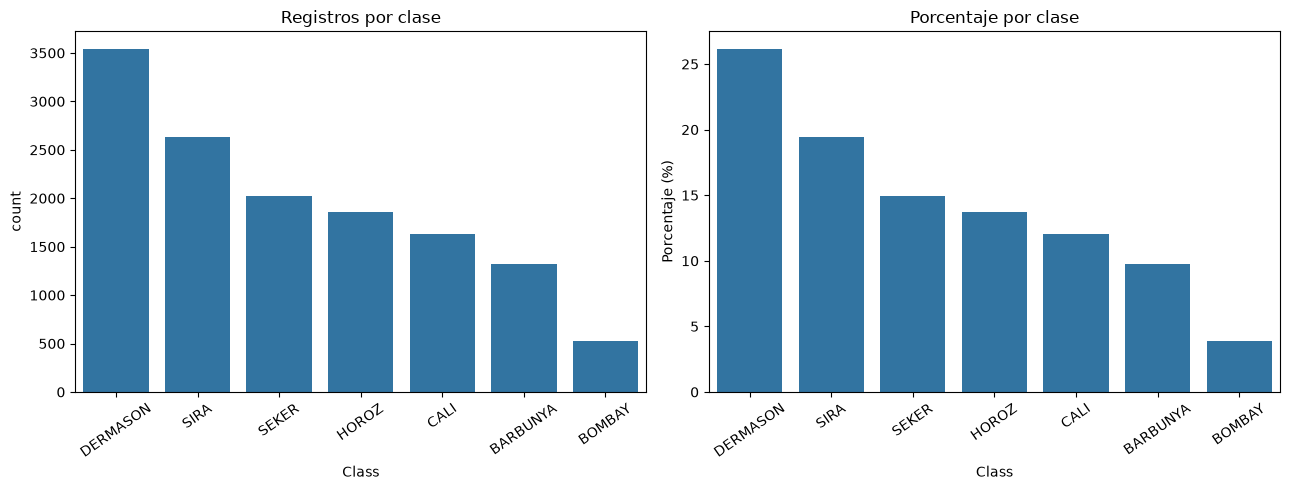

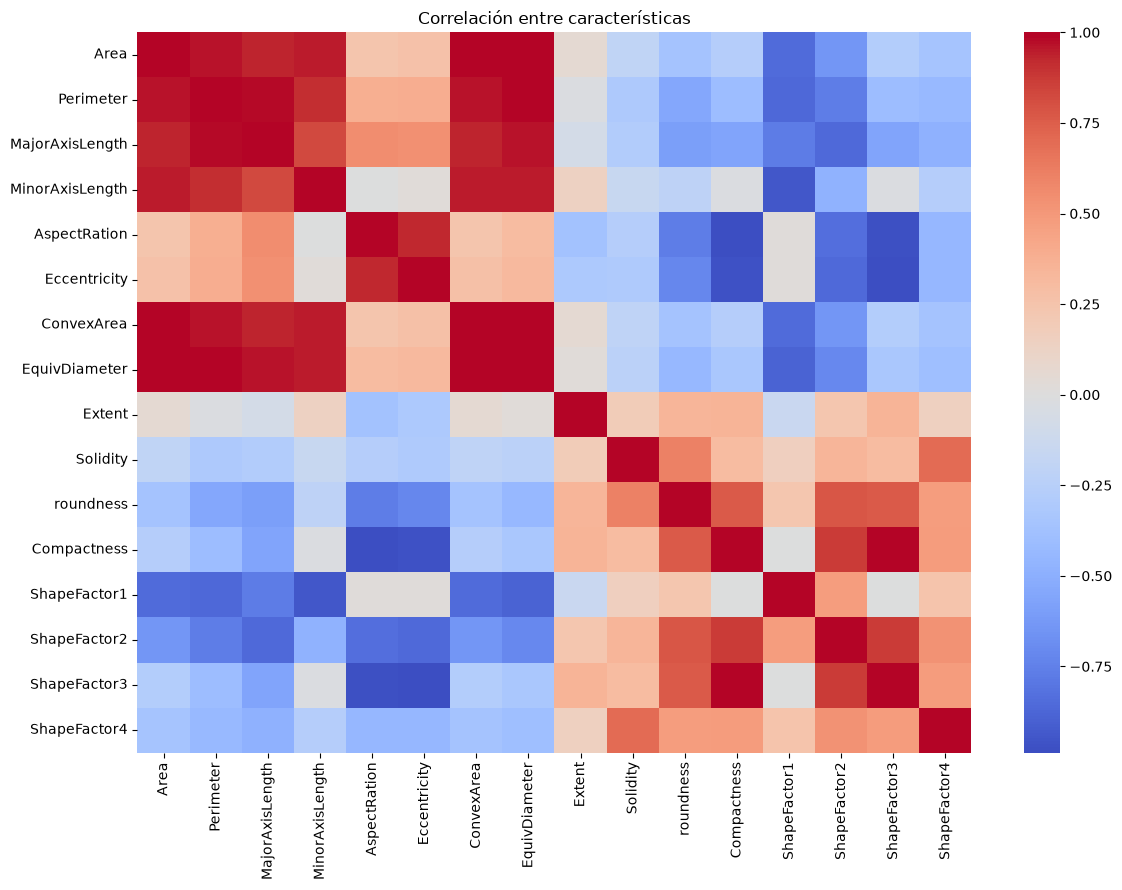

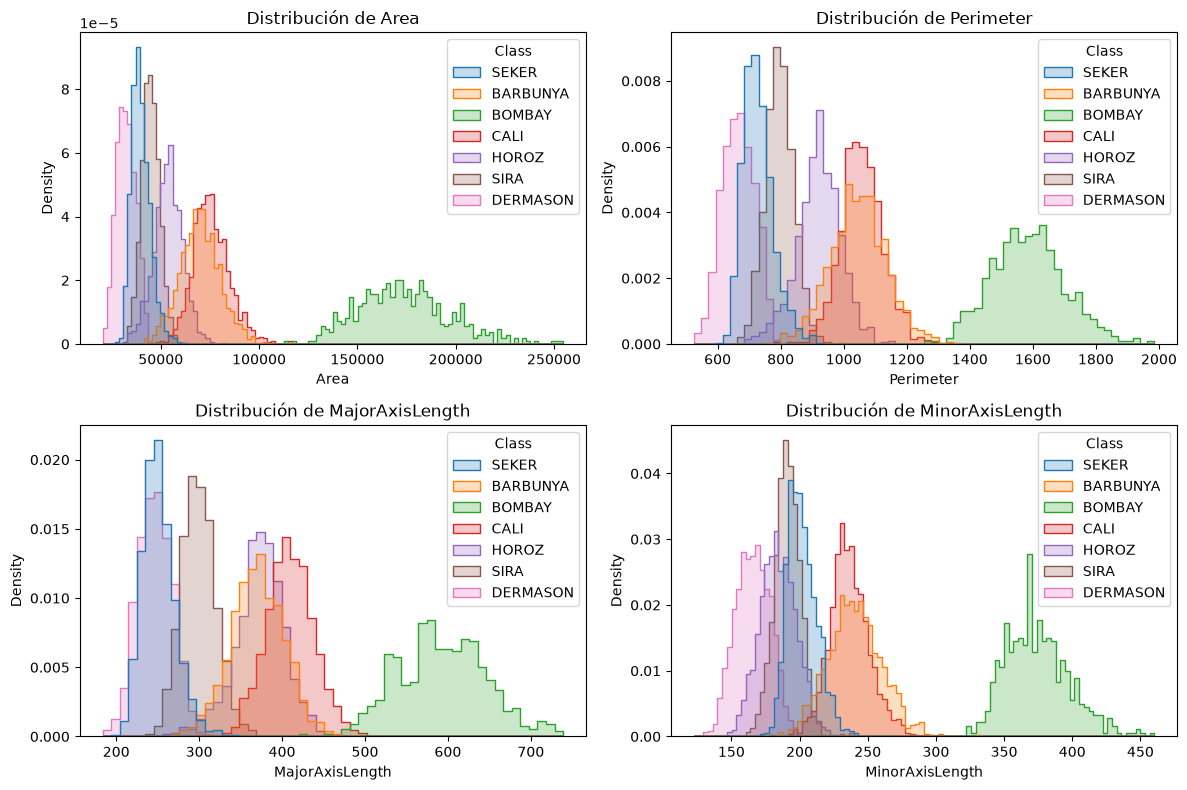


Codificación de clases:
   clase  codigo
BARBUNYA       0
  BOMBAY       1
    CALI       2
DERMASON       3
   HOROZ       4
   SEKER       5
    SIRA       6

Tamaños: train=9479 (69.99%), validation=2032 (15.00%), test=2032 (15.00%)
Media train (aprox.): -5.91057017772802e-16 Desv. estándar train (aprox.): 1.0
Dispositivo: cuda


MLP(
  (red): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Parámetros entrenables: 3399


Época 001: train_loss=0.9880, val_loss=0.3604, val_acc=0.8937


Época 010: train_loss=0.1891, val_loss=0.2010, val_acc=0.9267


Época 020: train_loss=0.1803, val_loss=0.2012, val_acc=0.9252


Época 030: train_loss=0.1736, val_loss=0.2017, val_acc=0.9232


Época 040: train_loss=0.1711, val_loss=0.1990, val_acc=0.9218


Época 050: train_loss=0.1673, val_loss=0.2015, val_acc=0.9208


Parada temprana en época 52


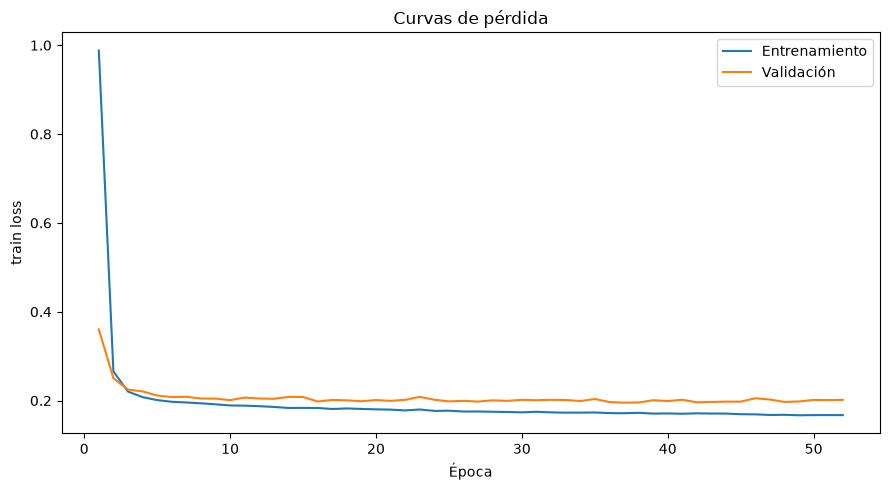

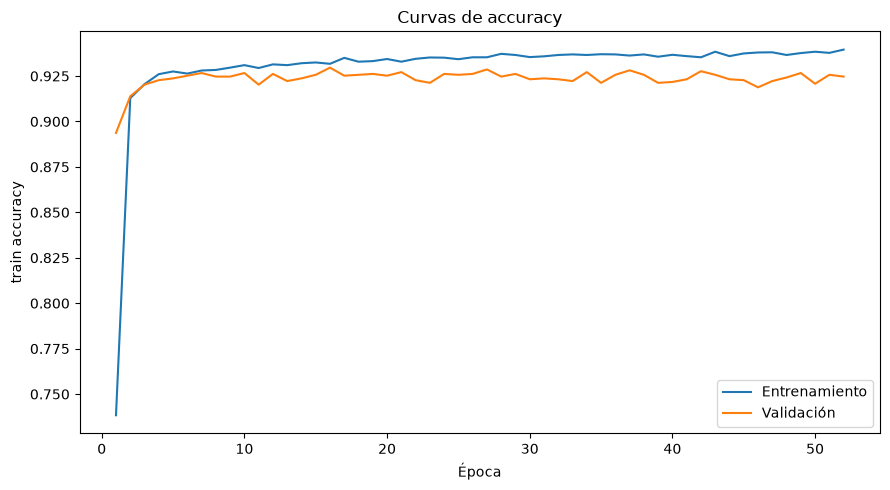

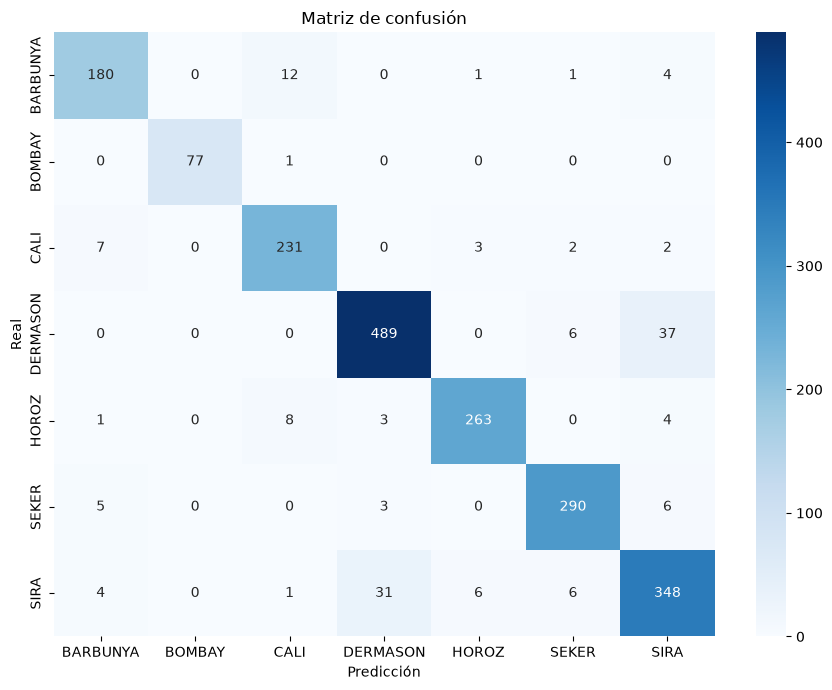

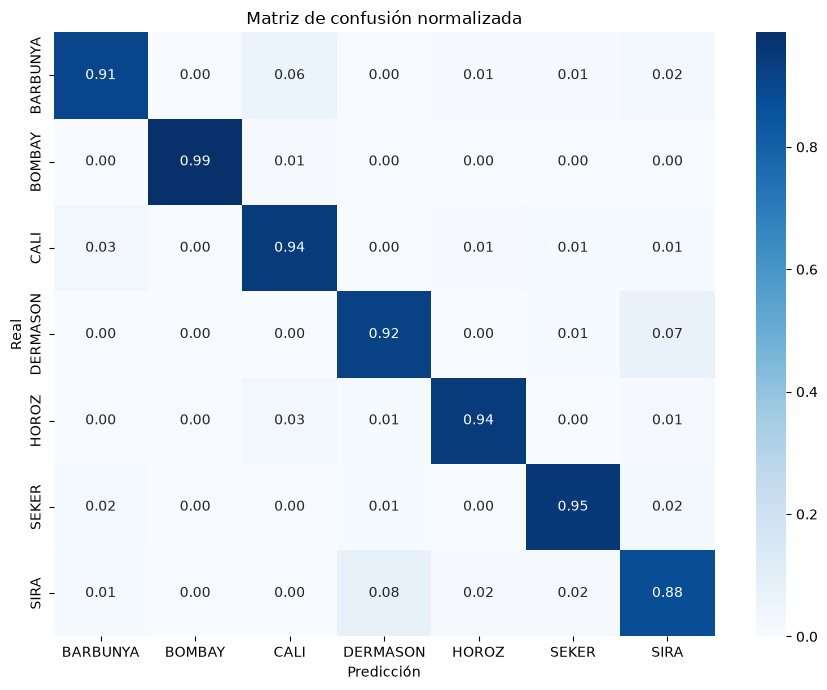


RESULTADOS FINALES:
test_loss              0.210601
accuracy               0.924213
precision_macro        0.934061
recall_macro           0.933384
f1_macro               0.933656
precision_weighted     0.924546
recall_weighted        0.924213
f1_weighted            0.924318
best_epoch            37.000000
best_val_loss          0.195311
dtype: float64

Principales confusiones:
DERMASON  SIRA        37.0
SIRA      DERMASON    31.0
BARBUNYA  CALI        12.0
HOROZ     CALI         8.0
CALI      BARBUNYA     7.0
dtype: float64

Resumen final de prueba:


,valor
test_loss,0.210601
accuracy,0.924213
precision_macro,0.934061
recall_macro,0.933384
f1_macro,0.933656
precision_weighted,0.924546
recall_weighted,0.924213
f1_weighted,0.924318
best_epoch,37.000000
best_val_loss,0.195311



Métricas por clase:


,precision,recall,f1-score,support
BARBUNYA,0.913706,0.909091,0.911392,198.000000
BOMBAY,1.000000,0.987179,0.993548,78.000000
CALI,0.913043,0.942857,0.927711,245.000000
DERMASON,0.929658,0.919173,0.924386,532.000000
HOROZ,0.963370,0.942652,0.952899,279.000000
SEKER,0.950820,0.953947,0.952381,304.000000
SIRA,0.867830,0.878788,0.873275,396.000000
accuracy,0.924213,0.924213,0.924213,0.924213
macro avg,0.934061,0.933384,0.933656,2032.000000
weighted avg,0.924546,0.924213,0.924318,2032.000000



Matriz de confusión:


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
BARBUNYA,180,0,12,0,1,1,4
BOMBAY,0,77,1,0,0,0,0
CALI,7,0,231,0,3,2,2
DERMASON,0,0,0,489,0,6,37
HOROZ,1,0,8,3,263,0,4
SEKER,5,0,0,3,0,290,6
SIRA,4,0,1,31,6,6,348


In [3]:
resultado = ejecutar_experimento(DATA_PATH, OUTPUTS_DIR, epochs=100, patience=15)
generar_graficas(DATA_PATH, OUTPUTS_DIR)
from IPython.display import Image, display
for figura in sorted(FIGURES_DIR.glob('*.png')):
    display(Image(filename=str(figura)))
historial = resultado['history']
resumen = pd.Series(resultado['summary'])
print()
print('Resumen final de prueba:')
display(resumen.to_frame('valor'))
print()
print('Métricas por clase:')
display(resultado['report'])
print()
print('Matriz de confusión:')
display(pd.DataFrame(resultado['confusion_matrix'], index=resultado['labels'], columns=resultado['labels']))

## 6. Evaluación e interpretación

La evaluación final incluye pérdida y accuracy de prueba, precision, recall y F1 por clase, promedios macro y ponderado, además de matrices de confusión absoluta y normalizada.

Para redactar las conclusiones, responde con los valores generados: porcentaje correctamente clasificado, clases con mayor y menor precision/recall/F1, variedades confundidas, señales de sobreajuste en las curvas, efecto del tamaño de las clases, importancia del F1 macro y limitaciones. Usa expresiones prudentes como *los resultados sugieren* y no atribuyas causas que el experimento no compruebe.

In [4]:
print(f"Accuracy de prueba: {resumen['accuracy']:.4%}")
print(f"F1 macro: {resumen['f1_macro']:.4%}")
print(f"Mejor época: {int(resumen['best_epoch'])}; pérdida de validación: {resumen['best_val_loss']:.6f}")
print('Archivos generados:')
for path in sorted(OUTPUTS_DIR.rglob('*')):
    if path.is_file(): print('-', path.relative_to(E1_DIR))

Accuracy de prueba: 92.4213%
F1 macro: 93.3656%
Mejor época: 37; pérdida de validación: 0.195311
Archivos generados:
- outputs\figuras\correlaciones.png
- outputs\figuras\curvas_accuracy.png
- outputs\figuras\curvas_perdida.png
- outputs\figuras\distribucion_clases.png
- outputs\figuras\histogramas.png
- outputs\figuras\matriz_confusion.png
- outputs\figuras\matriz_confusion_normalizada.png
- outputs\metricas\historial_entrenamiento.csv
- outputs\metricas\metricas_por_clase.csv
- outputs\metricas\resumen_metricas.csv
- outputs\modelos\mejor_modelo_mlp.pt


## Referencias

- UCI Machine Learning Repository, [Dry Bean Dataset](https://archive.ics.uci.edu/dataset/602/dry%2Bbean%2Bdataset).
- [Documentación oficial de PyTorch](https://pytorch.org/docs/stable/index.html).
- [StandardScaler de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).
- [Métricas de clasificación de scikit-learn](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).